# 07 · Ablation study and feature importance

Remove one feature group, retrain with M1's settings, recalibrate on 2022, score. Reporting only.

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import config
M = config.METRICS_DIR
def load(name):
    p = M / f"{name}.json"
    return json.loads(p.read_text()) if p.exists() else None
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7"})
C1, C2, C3 = "#2a78d6", "#eb6834", "#1baf7a"


In [2]:
a = load("ablation")
rows = {k: dict(n_features=v["n_features"], val_p20=v["val_2022"]["precision_at_k"], test_p20=v["test_2023_2025"]["precision_at_k"],
                d_test_p20=v["test_2023_2025"]["delta_precision_at_k_vs_full"], test_pr_auc=v["test_2023_2025"]["pr_auc"])
        for k, v in a.items() if not k.startswith("_")}
print(a["_not_built"]); pd.DataFrame(rows).T.round(4)

{'coherence': 'Sentinel-1 coherence needs SLC interferometric processing; not built in this run.', 'surrogate_velocity': 'Neural-operator surrogate (optional research track) not built.'}


,n_features,val_p20,test_p20,d_test_p20,test_pr_auc
full,23.0,0.4000,0.4231,0.0000,0.3780
-recent_retreat,19.0,0.3393,0.3769,-0.0462,0.3352
-history,21.0,0.3964,0.4085,-0.0146,0.3578
-channel_geometry,16.0,0.3768,0.4323,0.0092,0.3637
-water_level,18.0,0.3607,0.3908,-0.0323,0.3437
-season,21.0,0.3929,0.4192,-0.0038,0.3301
-neighbours,21.0,0.3875,0.4208,-0.0023,0.3831
-bank_height,22.0,0.3964,0.4185,-0.0046,0.3806


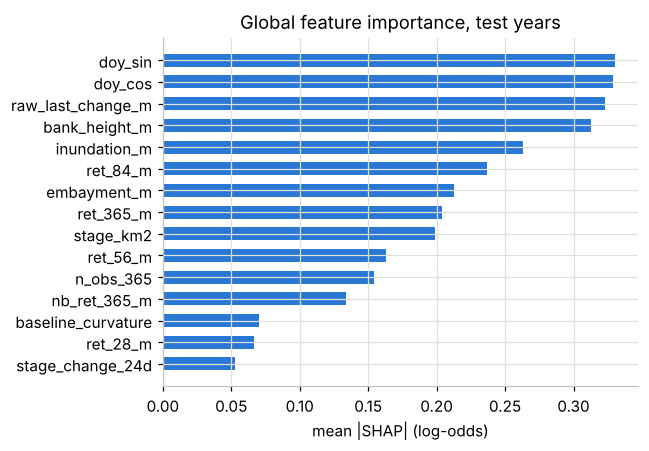

In [3]:
imp = pd.DataFrame(load("importance")).head(15)
fig, ax = plt.subplots(figsize=(6, 4.2)); ax.barh(imp.feature[::-1], imp.mean_abs_shap[::-1], color=C1, height=0.6)
ax.set_xlabel("mean |SHAP| (log-odds)"); ax.set_title("Global feature importance, test years"); plt.tight_layout(); plt.show()

/usr/local/lib/python3.13/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/usr/local/lib/python3.13/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


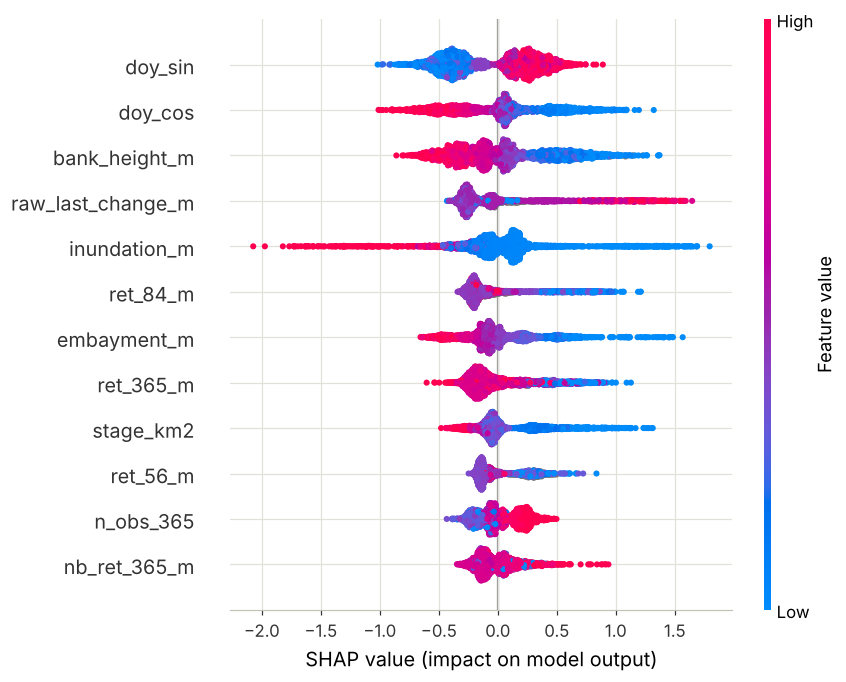

In [4]:
import shap
from src.models.train_lgbm import load_model, load_params
from src.models.data import load_dataset
model, info = load_model(), load_params()
df = load_dataset(); test = df[df.year.isin(config.TEST_YEARS)].sample(3000, random_state=0)
sv = shap.TreeExplainer(model).shap_values(test[info["features"]])
sv = sv[1] if isinstance(sv, list) else sv
shap.summary_plot(sv, test[info["features"]], show=False, max_display=12); plt.tight_layout(); plt.show()